In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

In [2]:
# Step 1: load data
def load(fp="mnist.npz"):
    if not os.path.exists(fp):
        raise FileNotFoundError(
            f"File not found: {fp}\n"
            f"Current folder: {os.getcwd()}\n"
            f"Files here: {os.listdir()}"
        )
    d = np.load(fp)
    return d["x_train"], d["y_train"], d["x_test"], d["y_test"]



In [3]:
# Step 2: filter + normalize
def prep(xtr, ytr, xte, yte, cls=(0,1,2)):
    m1 = np.isin(ytr, cls)
    m2 = np.isin(yte, cls)

    xtr, ytr = xtr[m1], ytr[m1]
    xte, yte = xte[m2], yte[m2]

    xtr = xtr.reshape(len(xtr), -1).astype(float)/255
    xte = xte.reshape(len(xte), -1).astype(float)/255

    return xtr, ytr, xte, yte



In [4]:
# Step 2: filter + normalize
def prep(xtr, ytr, xte, yte, cls=(0, 1, 2)):
    m1 = np.isin(ytr, cls)
    m2 = np.isin(yte, cls)

    xtr, ytr = xtr[m1], ytr[m1]
    xte, yte = xte[m2], yte[m2]

    xtr = xtr.reshape(len(xtr), -1).astype(float) / 255.0
    xte = xte.reshape(len(xte), -1).astype(float) / 255.0

    return xtr, ytr, xte, yte

In [5]:
# Step 3: PCA to reduced space
class PCA2:
    def __init__(self, k):
        self.k = k
        self.mu = None
        self.v = None

    def fit(self, X):
        self.mu = X.mean(axis=0)
        Xc = X - self.mu
        C = Xc.T @ Xc / Xc.shape[0]
        a, b = np.linalg.eigh(C)
        idx = np.argsort(a)[::-1]
        self.v = b[:, idx[:self.k]]
        return self

    def tr(self, X):
        return (X - self.mu) @ self.v

    def fit_tr(self, X):
        self.fit(X)
        return self.tr(X)

In [6]:
# Step 4: one-vs-rest targets
def oh(y, cls):
    Y = np.zeros((len(y), len(cls)))
    for i, c in enumerate(cls):
        Y[:, i] = (y == c).astype(float)
    return Y

In [7]:
# Step 5: shuffled train-val split
def split(X, Y, f=0.2, sd=42):
    rng = np.random.default_rng(sd)
    idx = rng.permutation(len(X))
    k = int(len(X) * f)
    iv = idx[:k]
    it = idx[k:]
    return X[it], Y[it], X[iv], Y[iv]

In [8]:
# Step 6: ridge regression
def ridge(X, Y, l):
    n = X.shape[0]
    Xb = np.hstack([np.ones((n, 1)), X])
    I = np.eye(Xb.shape[1])
    I[0, 0] = 0.0
    wb = np.linalg.solve(Xb.T @ Xb + l * I, Xb.T @ Y)
    return wb[1:], wb[0]


def pred_r(X, w, b):
    return X @ w + b


In [9]:
# Step 7: lasso regression
def lasso(X, Y, l):
    k = Y.shape[1]
    w = np.zeros((X.shape[1], k))
    b = np.zeros(k)

    for i in range(k):
        m = Lasso(alpha=l, max_iter=10000, fit_intercept=True)
        m.fit(X, Y[:, i])
        w[:, i] = m.coef_
        b[i] = m.intercept_

    return w, b


def pred_l(X, w, b):
    return X @ w + b

In [10]:
# Step 8: helpers
def mse(a, b):
    return np.mean((a - b) ** 2)

def nz(w, t=1e-4):
    return np.sum(np.abs(w) > t)

def pick(s):
    return np.argmax(s, axis=1)

def acc(y, yp, cls):
    yp2 = np.array([cls[i] for i in yp])
    return np.mean(yp2 == y)



Step 1: loading data
raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)

Step 2: filtering classes and flattening
filtered train: (18623, 784) (18623,)
filtered test : (3147, 784) (3147,)
classes in train: [0 1 2]
classes in test : [0 1 2]

Step 3: PCA with p = 10
xtr shape: (18623, 784)
ztr shape: (18623, 10)
zte shape: (3147, 10)
PCA matrix shape: (784, 10)
Reduced to 10 dims? True

Step 4: one-vs-rest targets
Ytr: (18623, 3)
Yte: (3147, 3)
row sum check: True

Step 5: train-validation split
Xt: (14899, 10) Yt: (14899, 3)
Xv: (3724, 10) Yv: (3724, 3)

Step 6: train Ridge and Lasso for all lambda
lambda= 0.0001 | ridge val mse=0.050240 | lasso val mse=0.050240 | lasso nonzero=30
lambda=  0.001 | ridge val mse=0.050240 | lasso val mse=0.050242 | lasso nonzero=30
lambda=   0.01 | ridge val mse=0.050240 | lasso val mse=0.050682 | lasso nonzero=29
lambda=    0.1 | ridge val mse=0.050240 | lasso val mse=0.064702 | lasso nonzero=10
lambda=      1 | ridge val mse=0.05024

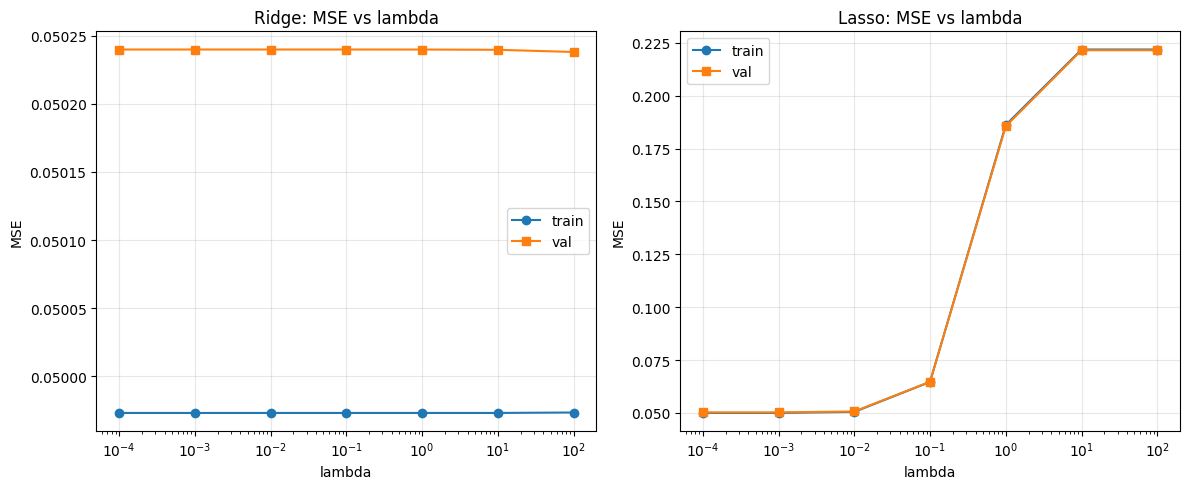

Step 9: plot lasso non-zero coefficients


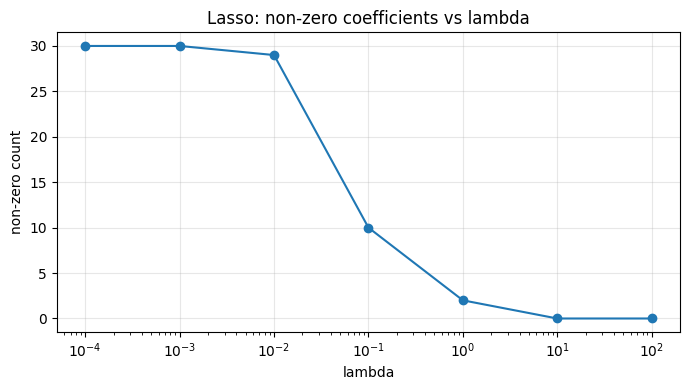

Step 10: plot regularization paths for one class


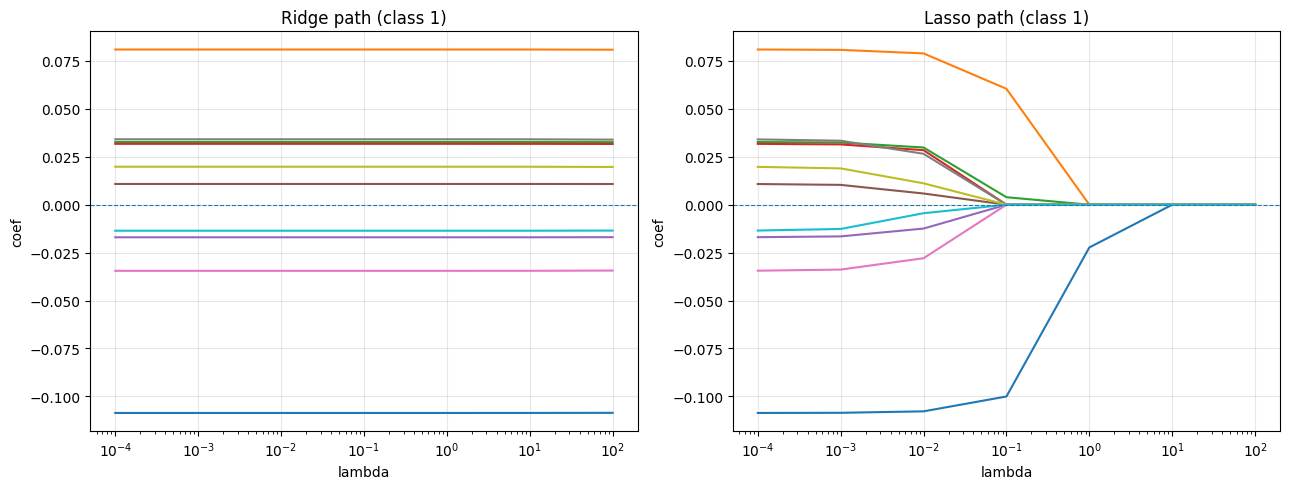

Step 11: best lambda from validation MSE
best ridge lambda: 100
best lasso lambda: 0.0001

Step 12: model complexity with ridge
p= 2 | ztr_k=(18623, 2) | train mse=0.067952 | val mse=0.068548
p= 5 | ztr_k=(18623, 5) | train mse=0.053726 | val mse=0.053992
p=10 | ztr_k=(18623, 10) | train mse=0.049973 | val mse=0.050238
p=20 | ztr_k=(18623, 20) | train mse=0.041641 | val mse=0.041922
p=30 | ztr_k=(18623, 30) | train mse=0.039224 | val mse=0.039582


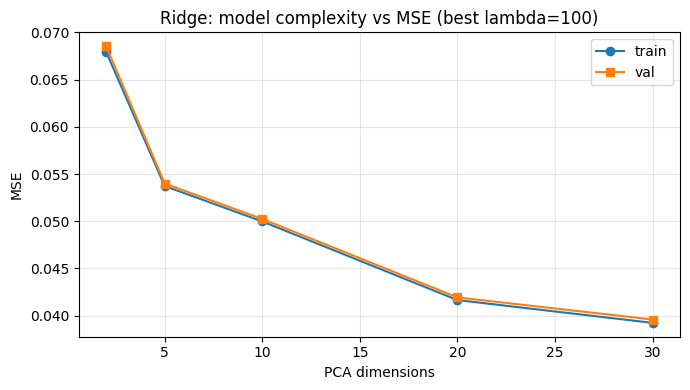


Step 13: test accuracy for best ridge and best lasso
ridge test accuracy: 0.9475691134413727
lasso test accuracy: 0.9475691134413727
ridge test accuracy %: 94.76
lasso test accuracy %: 94.76


In [11]:
# Step 9: full run
def main():
    cls = [0, 1, 2]
    lam = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

    print("Step 1: loading data")
    xr, yr, xs, ys = load("mnist.npz")
    print("raw train:", xr.shape, yr.shape)
    print("raw test :", xs.shape, ys.shape)
    print()

    print("Step 2: filtering classes and flattening")
    xtr, ytr, xte, yte = prep(xr, yr, xs, ys, cls)
    print("filtered train:", xtr.shape, ytr.shape)
    print("filtered test :", xte.shape, yte.shape)
    print("classes in train:", np.unique(ytr))
    print("classes in test :", np.unique(yte))
    print()

    print("Step 3: PCA with p = 10")
    p = PCA2(10)
    ztr = p.fit_tr(xtr)
    zte = p.tr(xte)
    print("xtr shape:", xtr.shape)
    print("ztr shape:", ztr.shape)
    print("zte shape:", zte.shape)
    print("PCA matrix shape:", p.v.shape)
    print("Reduced to 10 dims?", ztr.shape[1] == 10 and zte.shape[1] == 10)
    print()

    print("Step 4: one-vs-rest targets")
    Ytr = oh(ytr, cls)
    Yte = oh(yte, cls)
    print("Ytr:", Ytr.shape)
    print("Yte:", Yte.shape)
    print("row sum check:", np.all(Ytr.sum(axis=1) == 1))
    print()

    print("Step 5: train-validation split")
    Xt, Yt, Xv, Yv = split(ztr, Ytr, f=0.2, sd=42)
    print("Xt:", Xt.shape, "Yt:", Yt.shape)
    print("Xv:", Xv.shape, "Yv:", Yv.shape)
    print()

    print("Step 6: train Ridge and Lasso for all lambda")
    rtr, rval = [], []
    ltr, lval = [], []
    lnz = []

    rc = []
    lc = []

    for l in lam:
        wr, br = ridge(Xt, Yt, l)
        sr_t = pred_r(Xt, wr, br)
        sr_v = pred_r(Xv, wr, br)
        rtr.append(mse(Yt, sr_t))
        rval.append(mse(Yv, sr_v))
        rc.append(wr[:, 1].copy())

        wl, bl = lasso(Xt, Yt, l)
        sl_t = pred_l(Xt, wl, bl)
        sl_v = pred_l(Xv, wl, bl)
        ltr.append(mse(Yt, sl_t))
        lval.append(mse(Yv, sl_v))
        lnz.append(nz(wl))
        lc.append(wl[:, 1].copy())

        print(
            f"lambda={l:>7} | ridge val mse={rval[-1]:.6f} | "
            f"lasso val mse={lval[-1]:.6f} | lasso nonzero={lnz[-1]}"
        )
    print()

    print("Step 7: verify model output shapes")
    wr, br = ridge(Xt, Yt, lam[0])
    wl, bl = lasso(Xt, Yt, lam[0])
    print("ridge w,b:", wr.shape, br.shape)
    print("lasso w,b:", wl.shape, bl.shape)
    print("ridge pred:", pred_r(Xt, wr, br).shape)
    print("lasso pred:", pred_l(Xt, wl, bl).shape)
    print()

    print("Step 8: plot train/val MSE vs lambda")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].semilogx(lam, rtr, marker="o", label="train")
    ax[0].semilogx(lam, rval, marker="s", label="val")
    ax[0].set_title("Ridge: MSE vs lambda")
    ax[0].set_xlabel("lambda")
    ax[0].set_ylabel("MSE")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].semilogx(lam, ltr, marker="o", label="train")
    ax[1].semilogx(lam, lval, marker="s", label="val")
    ax[1].set_title("Lasso: MSE vs lambda")
    ax[1].set_xlabel("lambda")
    ax[1].set_ylabel("MSE")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Step 9: plot lasso non-zero coefficients")
    plt.figure(figsize=(7, 4))
    plt.semilogx(lam, lnz, marker="o")
    plt.title("Lasso: non-zero coefficients vs lambda")
    plt.xlabel("lambda")
    plt.ylabel("non-zero count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Step 10: plot regularization paths for one class")
    rc = np.array(rc)
    lc = np.array(lc)

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))

    for j in range(rc.shape[1]):
        ax[0].semilogx(lam, rc[:, j], label=f"f{j}")
    ax[0].axhline(0, linestyle="--", linewidth=0.8)
    ax[0].set_title("Ridge path (class 1)")
    ax[0].set_xlabel("lambda")
    ax[0].set_ylabel("coef")
    ax[0].grid(True, alpha=0.3)

    for j in range(lc.shape[1]):
        ax[1].semilogx(lam, lc[:, j], label=f"f{j}")
    ax[1].axhline(0, linestyle="--", linewidth=0.8)
    ax[1].set_title("Lasso path (class 1)")
    ax[1].set_xlabel("lambda")
    ax[1].set_ylabel("coef")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Step 11: best lambda from validation MSE")
    br_l = lam[np.argmin(rval)]
    bl_l = lam[np.argmin(lval)]
    print("best ridge lambda:", br_l)
    print("best lasso lambda:", bl_l)
    print()

    print("Step 12: model complexity with ridge")
    pp = [2, 5, 10, 20, 30]
    ctr, cval = [], []

    for k in pp:
        pk = PCA2(k)
        ztr_k = pk.fit_tr(xtr)
        zte_k = pk.tr(xte)

        Xt_k, Yt_k, Xv_k, Yv_k = split(ztr_k, Ytr, f=0.2, sd=42)

        wk, bk = ridge(Xt_k, Yt_k, br_l)
        ctr.append(mse(Yt_k, pred_r(Xt_k, wk, bk)))
        cval.append(mse(Yv_k, pred_r(Xv_k, wk, bk)))

        print(f"p={k:>2} | ztr_k={ztr_k.shape} | train mse={ctr[-1]:.6f} | val mse={cval[-1]:.6f}")

    plt.figure(figsize=(7, 4))
    plt.plot(pp, ctr, marker="o", label="train")
    plt.plot(pp, cval, marker="s", label="val")
    plt.title(f"Ridge: model complexity vs MSE (best lambda={br_l})")
    plt.xlabel("PCA dimensions")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print()
    print("Step 13: test accuracy for best ridge and best lasso")
    p10 = PCA2(10)
    ztr10 = p10.fit_tr(xtr)
    zte10 = p10.tr(xte)

    wr, br = ridge(ztr10, Ytr, br_l)
    wl, bl = lasso(ztr10, Ytr, bl_l)

    sr = pred_r(zte10, wr, br)
    sl = pred_l(zte10, wl, bl)

    yrp = pick(sr)
    ylp = pick(sl)

    ar = acc(yte, yrp, cls)
    al = acc(yte, ylp, cls)

    print("ridge test accuracy:", ar)
    print("lasso test accuracy:", al)
    print("ridge test accuracy %:", round(ar * 100, 2))
    print("lasso test accuracy %:", round(al * 100, 2))


if __name__ == "__main__":
    main()